In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("marketing.db")


In [2]:
query = """
SELECT
    t.channel,
    COUNT(DISTINCT t.user_id) AS users_reached,
    SUM(c.converted) AS conversions,
    1.0 * SUM(c.converted) / COUNT(DISTINCT t.user_id) AS conversion_rate,
    SUM(t.cost) AS spend,
    SUM(c.revenue) AS revenue,
    SUM(t.cost) / NULLIF(SUM(c.converted), 0) AS cac
FROM touchpoints t
LEFT JOIN conversions c ON t.user_id = c.user_id
GROUP BY t.channel
ORDER BY cac ASC;
"""
channel_perf = pd.read_sql(query, conn)
channel_perf


,channel,users_reached,conversions,conversion_rate,spend,revenue,cac
0,TikTok,10685,1524,0.142630,5359.40,18579.46,3.516667
1,YouTube,6708,753,0.112254,3251.58,9150.63,4.318167
2,Meta,13060,2284,0.174885,11009.39,27299.00,4.820223
3,Google_Search,11683,1876,0.160575,15259.20,22609.18,8.133902
4,Apple_Search_Ads,6810,834,0.122467,8306.55,10013.00,9.959892


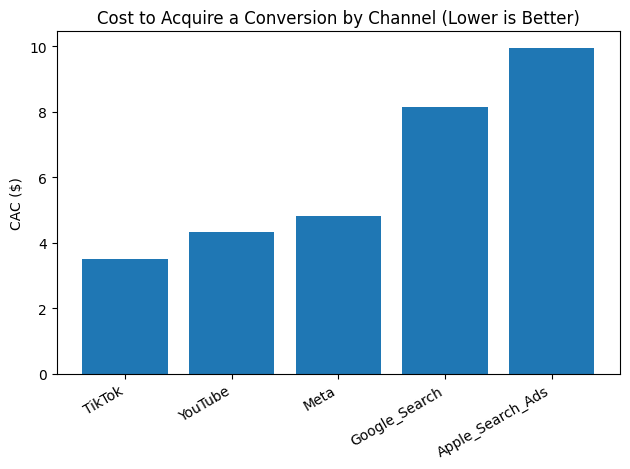

In [3]:
plt.figure()
plt.bar(channel_perf["channel"], channel_perf["cac"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("CAC ($)")
plt.title("Cost to Acquire a Conversion by Channel (Lower is Better)")
plt.tight_layout()
plt.show()


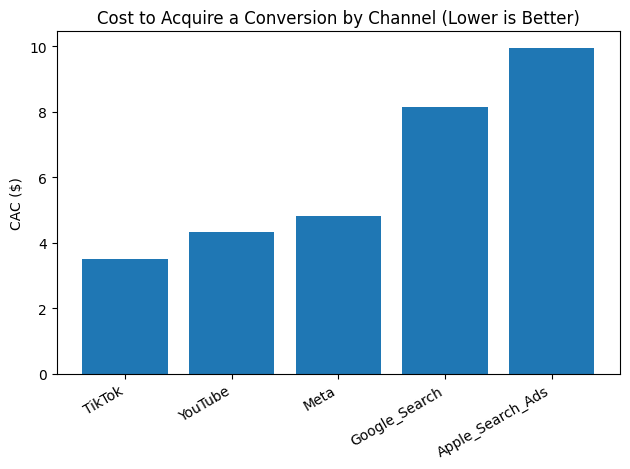

In [4]:
plt.figure()
plt.bar(channel_perf["channel"], channel_perf["cac"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("CAC ($)")
plt.title("Cost to Acquire a Conversion by Channel (Lower is Better)")
plt.tight_layout()
plt.savefig("cac_by_channel.png", dpi=200)
plt.show()


In [5]:
query = """
WITH base AS (
  SELECT
      c.country,
      g.is_test,
      CASE WHEN c.conversion_time >= g.experiment_start THEN 1 ELSE 0 END AS post,
      1.0 * SUM(CASE WHEN c.converted = 1 THEN 1 ELSE 0 END) / COUNT(*) AS conversion_rate
  FROM conversions c
  JOIN geo_experiment g ON c.country = g.country
  GROUP BY 1,2,3
)
SELECT * FROM base
ORDER BY is_test DESC, country, post;
"""
base = pd.read_sql(query, conn)
base


,country,is_test,post,conversion_rate
0,DE,1,0,0.075359
1,DE,1,1,0.080851
2,FR,1,0,0.087760
3,FR,1,1,0.091887
4,GB,1,0,0.086240
5,GB,1,1,0.092319
6,US,1,0,0.077703
7,US,1,1,0.089207
8,BR,0,0,0.071038
9,BR,0,1,0.084291


In [6]:
test_pre = base[(base.is_test==1) & (base.post==0)]["conversion_rate"].mean()
test_post = base[(base.is_test==1) & (base.post==1)]["conversion_rate"].mean()
ctrl_pre = base[(base.is_test==0) & (base.post==0)]["conversion_rate"].mean()
ctrl_post = base[(base.is_test==0) & (base.post==1)]["conversion_rate"].mean()

lift = (test_post - test_pre) - (ctrl_post - ctrl_pre)

test_pre, test_post, ctrl_pre, ctrl_post, lift


(np.float64(0.08176541992433936),
 np.float64(0.08856588022378656),
 np.float64(0.0804533690230844),
 np.float64(0.0767627829965321),
 np.float64(0.010491046325999509))

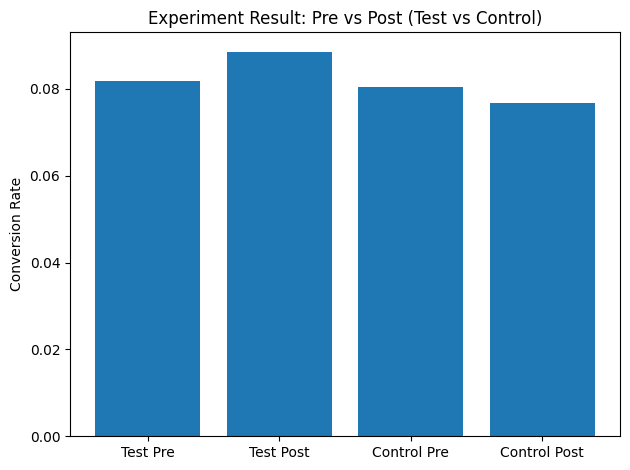

Incremental lift (DiD): 0.0105


In [7]:
labels = ["Test Pre", "Test Post", "Control Pre", "Control Post"]
values = [test_pre, test_post, ctrl_pre, ctrl_post]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Conversion Rate")
plt.title("Experiment Result: Pre vs Post (Test vs Control)")
plt.tight_layout()
plt.show()

print("Incremental lift (DiD):", round(lift, 4))


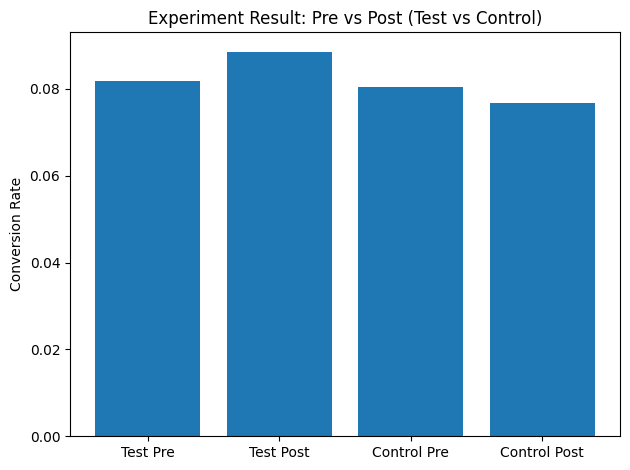

In [8]:
plt.figure()
plt.bar(labels, values)
plt.ylabel("Conversion Rate")
plt.title("Experiment Result: Pre vs Post (Test vs Control)")
plt.tight_layout()
plt.savefig("experiment_pre_post.png", dpi=200)
plt.show()
